In [3]:
import os
import gc
import json
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.utils import resample
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, precision_score
# --- CONFIGURAÇÕES --
PASTAS_DATASET = [
    'imagens_acrais_benignas',
    'imagens_acrais_maligno'
]

CAMINHO_MODELOS = 'Modelos'



In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Permite que o TF aloque memória gradualmente conforme a necessidade
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"Erro na config da GPU: {e}")

E0000 00:00:1778511850.810578   46894 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# Definir Presets
TAMANHO_IMAGEM = (224, 224)

# CARREGAR E COMBINAR METADADOS ---
dfs = []
for pasta in PASTAS_DATASET:
    caminho_csv = os.path.join(pasta, 'metadata.csv')
    if os.path.exists(caminho_csv):
        df_temp = pd.read_csv(caminho_csv)
        # Cria uma nova coluna com o caminho completo da imagem para facilitar
        df_temp['caminho_imagem'] = df_temp['isic_id'].apply(lambda x: os.path.join(pasta, f"{x}.jpg"))
        dfs.append(df_temp)
    else:
        print(f"Aviso: {caminho_csv} não encontrado.")

# Junta os CSVs das duas pastas em um só DataFrame
df_completo = pd.concat(dfs, ignore_index=True)

# FILTRAR DATASET (Usando todas as imagens disponíveis) ---
## 1. Primeiro, removemos duplicatas baseadas no ID único e verificamos existência física
df_unico = df_completo.drop_duplicates(subset='isic_id')
df_existente = df_unico[df_unico['caminho_imagem'].apply(os.path.exists)].copy()

## 2. Separar as classes sem limite de amostras
df_benigno = df_existente[df_existente['diagnosis_1'] == 'Benign']
df_maligno = df_existente[df_existente['diagnosis_1'] == 'Malignant']

## 3. Combinar e embaralhar o dataset final com tudo que foi encontrado
df_filtrado = pd.concat([df_benigno, df_maligno]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset total criado com {len(df_filtrado)} imagens (Benignas: {len(df_benigno)}, Malignas: {len(df_maligno)}).")

Dataset total criado com 2059 imagens (Benignas: 1557, Malignas: 502).


## Dataset extra (ISIC-images) somente para teste

In [5]:
# === PREPARAÇÃO DO DATASET DE TESTE: ISIC-images ===
print("=== PREPARANDO DATASET DE TESTE: ISIC-images ===\n")

PASTA_ISIC = 'ISIC-images'

# Carrega os metadados do dataset ISIC-images
df_isic = pd.read_csv(os.path.join(PASTA_ISIC, 'metadata.csv'))

# Cria coluna com o caminho completo de cada imagem
df_isic['caminho_imagem'] = df_isic['isic_id'].apply(
    lambda x: os.path.join(PASTA_ISIC, f"{x}.jpg")
)

# Remove duplicatas por isic_id
df_isic = df_isic.drop_duplicates(subset='isic_id')

# Verifica existência física das imagens no disco
df_isic = df_isic[df_isic['caminho_imagem'].apply(os.path.exists)].copy()

# Filtra apenas as classes de interesse (Benign e Malignant)
df_isic_filtrado = df_isic[df_isic['diagnosis_1'].isin(['Benign', 'Malignant'])].copy()
df_isic_filtrado = df_isic_filtrado.reset_index(drop=True)

# Estatísticas do dataset organizado
n_total    = len(df_isic_filtrado)
n_benign   = len(df_isic_filtrado[df_isic_filtrado['diagnosis_1'] == 'Benign'])
n_malignant = len(df_isic_filtrado[df_isic_filtrado['diagnosis_1'] == 'Malignant'])

print(f"Dataset ISIC-images organizado com sucesso!")
print(f"  Total de imagens : {n_total}")
print(f"  Benignas         : {n_benign}")
print(f"  Malignas         : {n_malignant}")
print(f"\nDistribuição das classes:")
print(df_isic_filtrado['diagnosis_1'].value_counts())


=== PREPARANDO DATASET DE TESTE: ISIC-images ===

Dataset ISIC-images organizado com sucesso!
  Total de imagens : 666
  Benignas         : 522
  Malignas         : 144

Distribuição das classes:
diagnosis_1
Benign       522
Malignant    144
Name: count, dtype: int64


## Data Augmentation

In [6]:
print("=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===")

TAMANHO_B0 = (224, 224)
BATCH_SIZE = 32

# Validação: 20% do df_filtrado, sem augmentation (métricas mais estáveis)
datagen_val = ImageDataGenerator(validation_split=0.2)
val_gen = datagen_val.flow_from_dataframe(
    dataframe=df_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)

# Oversampling da classe minoritária até igualar a majoritária
df_malignant = df_filtrado[df_filtrado["diagnosis_1"] == "Malignant"]
df_benign = df_filtrado[df_filtrado["diagnosis_1"] == "Benign"]
maior_classe = max(len(df_malignant), len(df_benign))
df_benign_upsampled = resample(
    df_benign, replace=True, n_samples=maior_classe, random_state=42
)
df_malignant_upsampled = resample(
    df_malignant, replace=True, n_samples=maior_classe, random_state=42
)
df_equilibrado = pd.concat([df_malignant_upsampled, df_benign_upsampled]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"Treino equilibrado: {len(df_equilibrado)} imagens")
print(df_equilibrado["diagnosis_1"].value_counts())

datagen_balanced = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=45,       # Rotação padrão (o artigo não especifica 360, então usamos um valor moderado comum)
    width_shift_range=0.1,   # Translações horizontais
    height_shift_range=0.1,  # Translações verticais
    horizontal_flip=True,    # Flips aleatórios
    vertical_flip=True       # Flips aleatórios
    # Sem zoom, sem alteração de cor, sem shear.
)

train_gen_balanced = datagen_balanced.flow_from_dataframe(
    dataframe=df_equilibrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===
Found 411 validated image filenames belonging to 2 classes.


Treino equilibrado: 3114 imagens
diagnosis_1
Malignant    1557
Benign       1557
Name: count, dtype: int64
Found 3114 validated image filenames belonging to 2 classes.


## Treinamento de 6 modelos
Variando
- Taxa de aprendizado (LR): 1e-4, 1e-5
- Nº de blocos do EfficientNetB0 descongelados (a partir do topo): 1, 2, 3
* 1 -> apenas block7 + camadas top_*
* 2 -> blocks 6 e 7 + top_*
* 3 -> blocks 5, 6 e 7 + top_*
- Dropout fixo em 0.4 (para isolar o efeito das duas variáveis estudadas)

In [6]:
# === GRID SEARCH (6 TESTES: 2 LRs x 3 nº de blocos descongelados) ===
PASTA_MODELOS_UL = os.path.join(CAMINHO_MODELOS, "grid_unfrozen")
os.makedirs(PASTA_MODELOS_UL, exist_ok=True)

learning_rates_ul       = [1e-4, 1e-5]
unfrozen_blocks_list    = [1, 2, 3]
DROPOUT_UL              = 0.4

historicos_grid_ul = {}


def descongelar_ultimos_n_blocos(base_model, n_blocos):
    """Congela toda a base e descongela os últimos n blocos (block{7-n+1}..block7)
    junto com as camadas finais (top_*). Mantém BatchNorm congelado."""
    base_model.trainable = False
    blocos_descongelar = set(range(7 - n_blocos + 1, 8))  # ex.: n=2 -> {6,7}
    for layer in base_model.layers:
        deve_descongelar = (
            any(layer.name.startswith(f"block{b}") for b in blocos_descongelar)
            or layer.name.startswith("top_")
        )
        if deve_descongelar and not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False
    n_treinaveis = sum(int(np.prod(w.shape)) for w in base_model.trainable_weights)
    return n_treinaveis


print("=== INICIANDO GRID SEARCH (6 TESTES: LR x Nº blocos descongelados) ===")

for lr in learning_rates_ul:
    for n_unf in unfrozen_blocks_list:

        nome_teste   = f"LR{lr}_UL{n_unf}"
        nome_arquivo = os.path.join(PASTA_MODELOS_UL, f"{nome_teste}.keras")

        print("\n" + "=" * 60)
        print(f"INICIANDO TESTE: {nome_teste}")
        print(f"Learning Rate: {lr} | Blocos descongelados: {n_unf} | Dropout: {DROPOUT_UL}")
        print("=" * 60)

        tf.keras.backend.clear_session()
        gc.collect()

        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3),
        )
        n_treinaveis = descongelar_ultimos_n_blocos(base_model, n_unf)
        print(f"Parâmetros treináveis na base (sem BN): {n_treinaveis:,}")

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(DROPOUT_UL)(x)
        saida = Dense(1, activation="sigmoid")(x)
        modelo_cnn = Model(inputs=base_model.input, outputs=saida)

        modelo_cnn.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
        )

        callbacks_lista = [
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
            ModelCheckpoint(
                filepath=nome_arquivo,
                monitor="val_recall",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=0),
        ]

        print(f"Treinando modelo {nome_teste}...")
        history = modelo_cnn.fit(
            train_gen_balanced,
            validation_data=val_gen,
            epochs=20,
            callbacks=callbacks_lista,
            verbose=1,
        )
        historicos_grid_ul[nome_teste] = history.history

with open(os.path.join(PASTA_MODELOS_UL, "historicos_grid.json"), "w") as f:
    json.dump(
        {k: {m: list(map(float, v)) for m, v in h.items()} for k, h in historicos_grid_ul.items()},
        f,
    )

print("\n✅ GRID SEARCH (LR x UL) CONCLUÍDO COM SUCESSO!")
print(f"Arquivos salvos em '{PASTA_MODELOS_UL}/'.")

=== INICIANDO GRID SEARCH (6 TESTES: LR x Nº blocos descongelados) ===

INICIANDO TESTE: LR0.0001_UL1
Learning Rate: 0.0001 | Blocos descongelados: 1 | Dropout: 0.4


W0000 00:00:1778165890.891349    1293 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Parâmetros treináveis na base (sem BN): 0
Treinando modelo LR0.0001_UL1...
Epoch 1/20


I0000 00:00:1778165895.451721    1293 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8034 - loss: 0.4137 - recall: 0.7781
Epoch 1: val_recall improved from None to 0.97959, saving model to Modelos/grid_unfrozen/LR0.0001_UL1.keras

Epoch 1: finished saving model to Modelos/grid_unfrozen/LR0.0001_UL1.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.8603 - loss: 0.3240 - recall: 0.8632 - val_accuracy: 0.8978 - val_loss: 0.2458 - val_recall: 0.9796 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8988 - loss: 0.2333 - recall: 0.9264
Epoch 2: val_recall did not improve from 0.97959
98/98 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.9056 - loss: 0.2143 - recall: 0.9216 - val_accuracy: 0.9197 - val_loss: 0.1758 - val_recall: 0.9796 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9284 - loss: 0.1826 - recall: 0.9499
Epoch 3: val_recall improved from 0.97959 to 0.98980, saving model to Modelos/grid_unfrozen/LR0.0001_UL1.keras

Ep

### Avaliação dos modelos 
Avaliando os modelos treinados em relação a Learning Rate e Número de Camadas descongeladas, utilizando dropout fixo de 0.4

=== TESTANDO OS 6 MODELOS NOS DOIS CONJUNTOS ===

Found 666 validated image filenames belonging to 2 classes.
[Teste padrão] Mapeamento de classes : {'Benign': 0, 'Malignant': 1}
[Teste padrão] Total de amostras     : 411
[ISIC-images] Mapeamento de classes : {'Benign': 0, 'Malignant': 1}
[ISIC-images] Total de amostras     : 666


📊  AVALIANDO MODELO: LR0.0001_UL1


E0000 00:00:1778512234.307631   37098 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1778512236.240654   37098 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 925ms/step

[Teste padrão] Relatório de Classificação (LR0.0001_UL1):
              precision    recall  f1-score   support

      Benign     1.0000    0.9329    0.9653       313
   Malignant     0.8235    1.0000    0.9032        98

    accuracy                         0.9489       411
   macro avg     0.9118    0.9665    0.9343       411
weighted avg     0.9579    0.9489    0.9505       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 692ms/step

[ISIC-images] Relatório de Classificação (LR0.0001_UL1):
              precision    recall  f1-score   support

      Benign     0.9350    0.9368    0.9359       522
   Malignant     0.7692    0.7639    0.7666       144

    accuracy                         0.8994       666
   macro avg     0.8521    0.8503    0.8512       666
weighted avg     0.8992    0.8994    0.8993       666



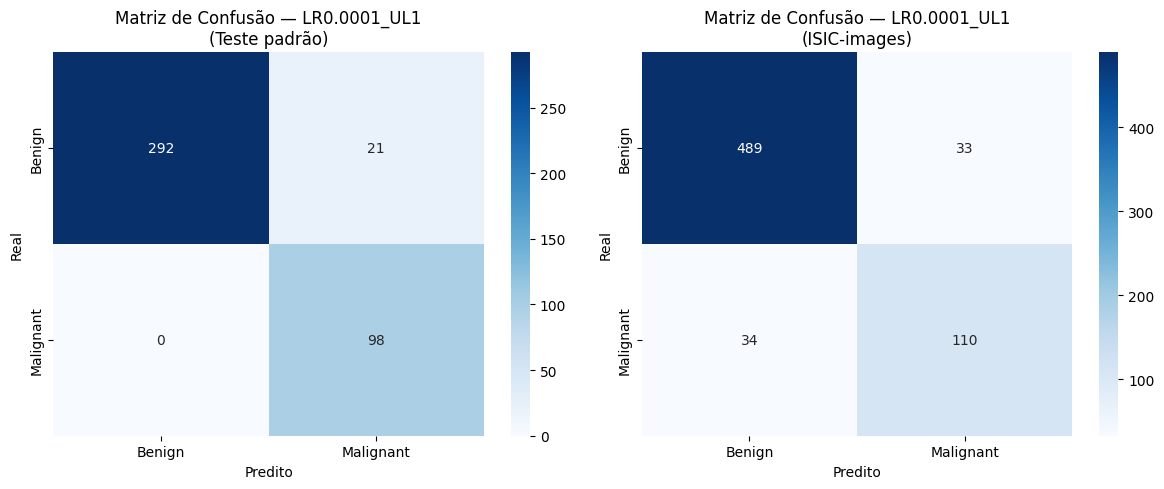


📊  AVALIANDO MODELO: LR0.0001_UL2
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step 

[Teste padrão] Relatório de Classificação (LR0.0001_UL2):
              precision    recall  f1-score   support

      Benign     1.0000    0.9457    0.9721       313
   Malignant     0.8522    1.0000    0.9202        98

    accuracy                         0.9586       411
   macro avg     0.9261    0.9728    0.9461       411
weighted avg     0.9648    0.9586    0.9597       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 747ms/step

[ISIC-images] Relatório de Classificação (LR0.0001_UL2):
              precision    recall  f1-score   support

      Benign     0.9369    0.9387    0.9378       522
   Malignant     0.7762    0.7708    0.7735       144

    accuracy                         0.9024       666
   macro avg     0.8566    0.8548    0.8557       666
weighted avg     0.9022    0.9024    0.9023       666



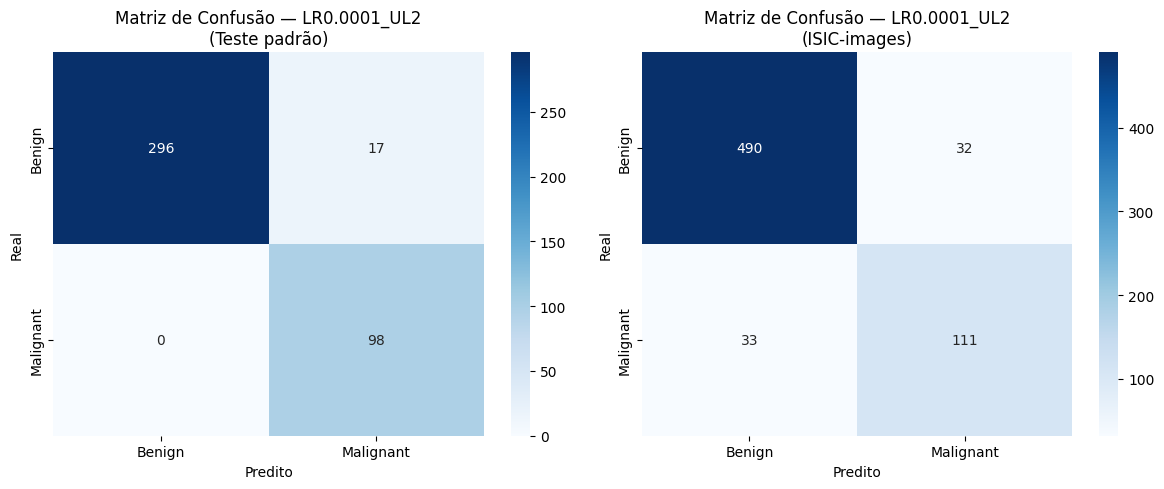


📊  AVALIANDO MODELO: LR0.0001_UL3
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step

[Teste padrão] Relatório de Classificação (LR0.0001_UL3):
              precision    recall  f1-score   support

      Benign     1.0000    0.9073    0.9514       313
   Malignant     0.7717    1.0000    0.8711        98

    accuracy                         0.9294       411
   macro avg     0.8858    0.9537    0.9113       411
weighted avg     0.9456    0.9294    0.9323       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 719ms/step

[ISIC-images] Relatório de Classificação (LR0.0001_UL3):
              precision    recall  f1-score   support

      Benign     0.9508    0.9253    0.9379       522
   Malignant     0.7532    0.8264    0.7881       144

    accuracy                         0.9039       666
   macro avg     0.8520    0.8758    0.8630       666
weighted avg     0.9081    0.9039    0.9055       666



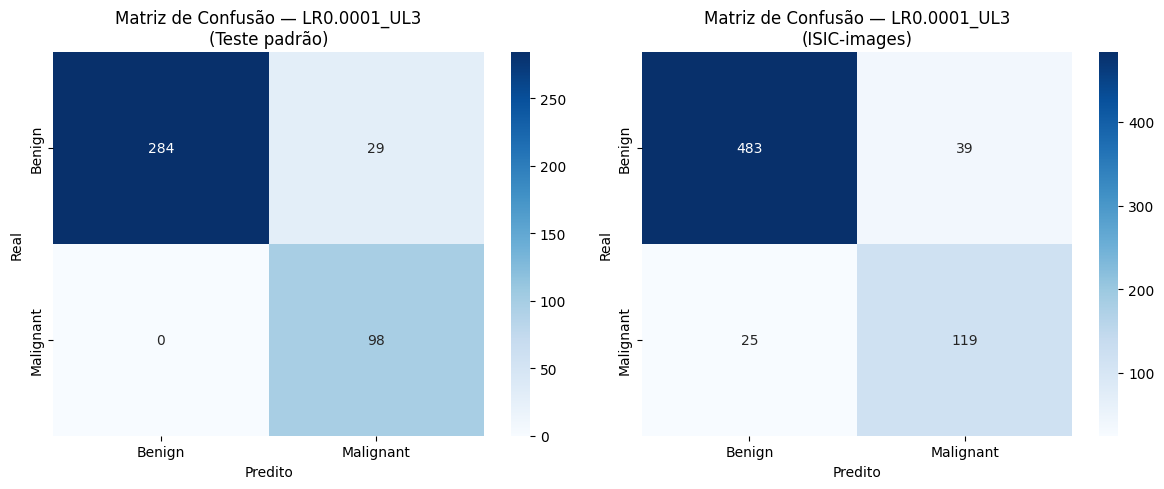


📊  AVALIANDO MODELO: LR1e-05_UL1
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step 

[Teste padrão] Relatório de Classificação (LR1e-05_UL1):
              precision    recall  f1-score   support

      Benign     0.9965    0.9042    0.9481       313
   Malignant     0.7638    0.9898    0.8622        98

    accuracy                         0.9246       411
   macro avg     0.8801    0.9470    0.9051       411
weighted avg     0.9410    0.9246    0.9276       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 749ms/step

[ISIC-images] Relatório de Classificação (LR1e-05_UL1):
              precision    recall  f1-score   support

      Benign     0.9253    0.9023    0.9137       522
   Malignant     0.6752    0.7361    0.7043       144

    accuracy                         0.8664       666
   macro avg     0.8003    0.8192    0.8090       666
weighted avg     0.8712    0.8664    0.8684       666



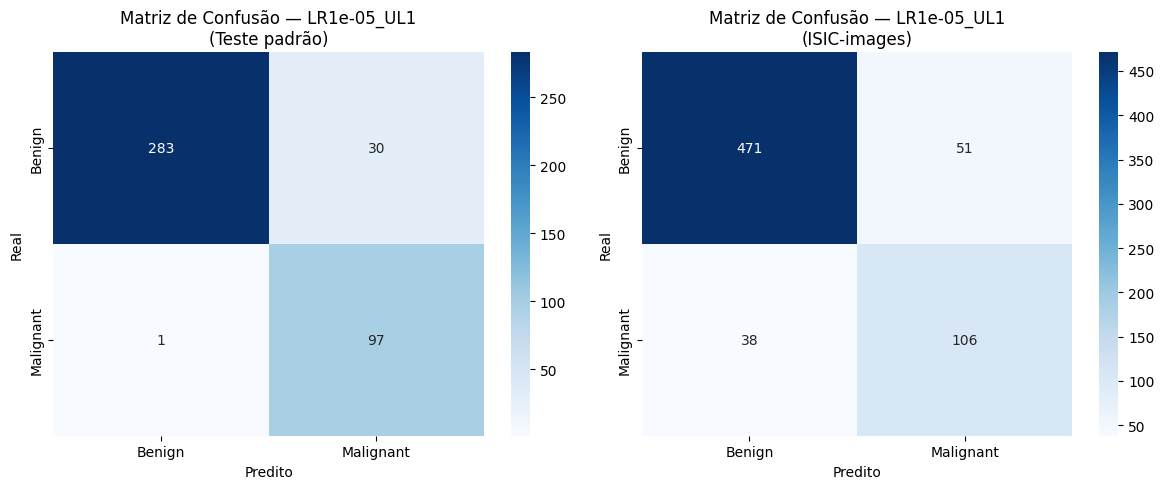


📊  AVALIANDO MODELO: LR1e-05_UL2
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

[Teste padrão] Relatório de Classificação (LR1e-05_UL2):
              precision    recall  f1-score   support

      Benign     1.0000    0.9105    0.9532       313
   Malignant     0.7778    1.0000    0.8750        98

    accuracy                         0.9319       411
   macro avg     0.8889    0.9553    0.9141       411
weighted avg     0.9470    0.9319    0.9345       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 811ms/step

[ISIC-images] Relatório de Classificação (LR1e-05_UL2):
              precision    recall  f1-score   support

      Benign     0.9322    0.9215    0.9268       522
   Malignant     0.7267    0.7569    0.7415       144

    accuracy                         0.8859       666
   macro avg     0.8294    0.8392    0.8341       666
weighted avg     0.8877    0.8859    0.8867       666



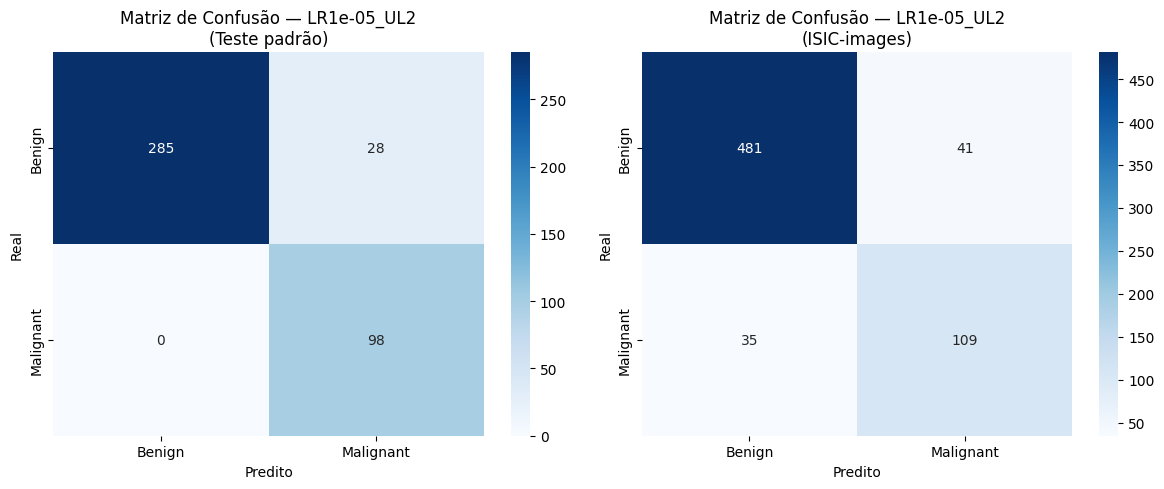


📊  AVALIANDO MODELO: LR1e-05_UL3
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step

[Teste padrão] Relatório de Classificação (LR1e-05_UL3):
              precision    recall  f1-score   support

      Benign     1.0000    0.8882    0.9408       313
   Malignant     0.7368    1.0000    0.8485        98

    accuracy                         0.9148       411
   macro avg     0.8684    0.9441    0.8946       411
weighted avg     0.9373    0.9148    0.9188       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 812ms/step

[ISIC-images] Relatório de Classificação (LR1e-05_UL3):
              precision    recall  f1-score   support

      Benign     0.9402    0.8736    0.9057       522
   Malignant     0.6354    0.7986    0.7077       144

    accuracy                         0.8574       666
   macro avg     0.7878    0.8361    0.8067       666
weighted avg     0.8743    0.8574    0.8629       666



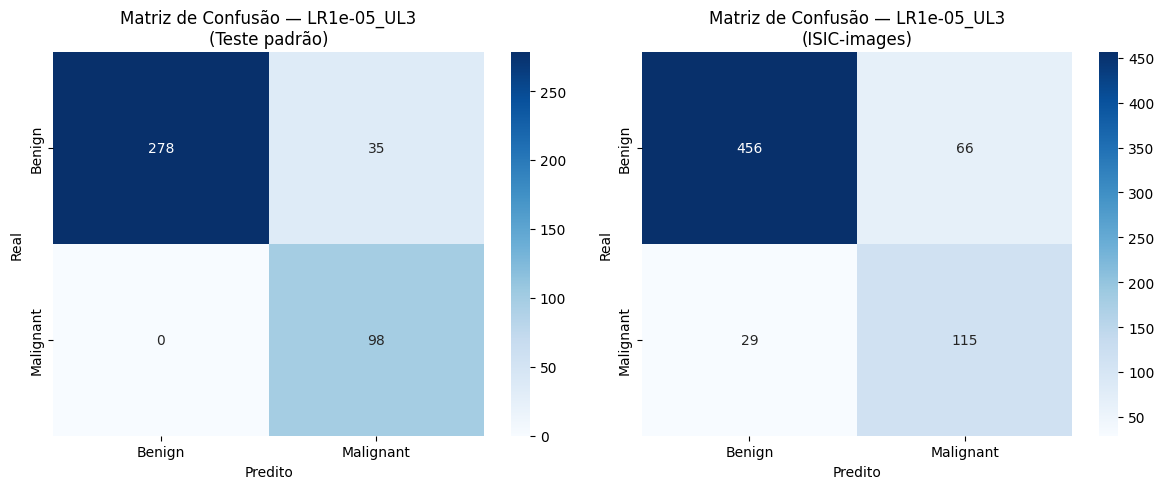


✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!


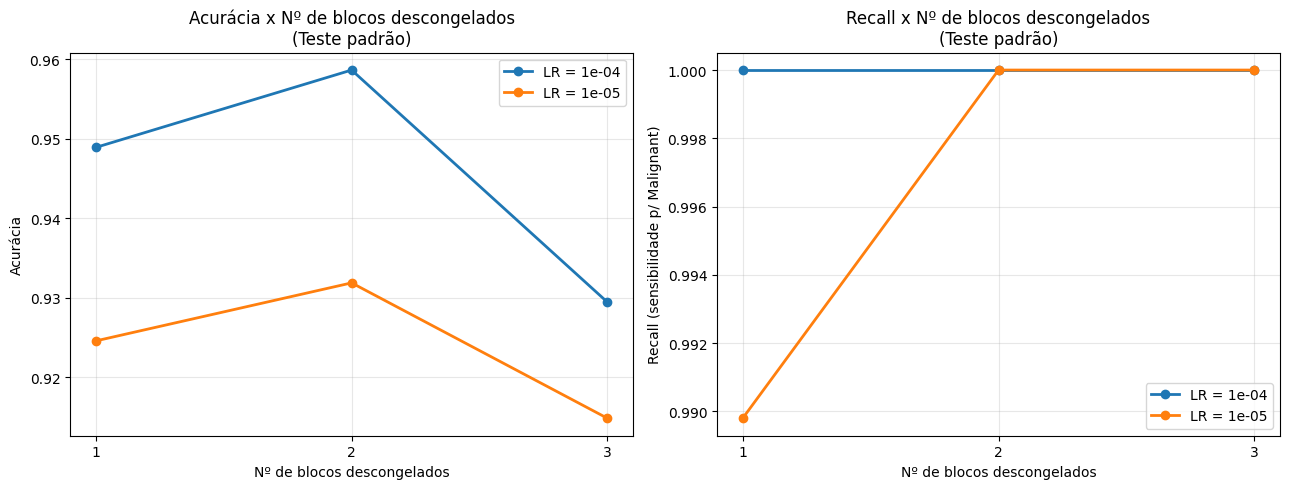

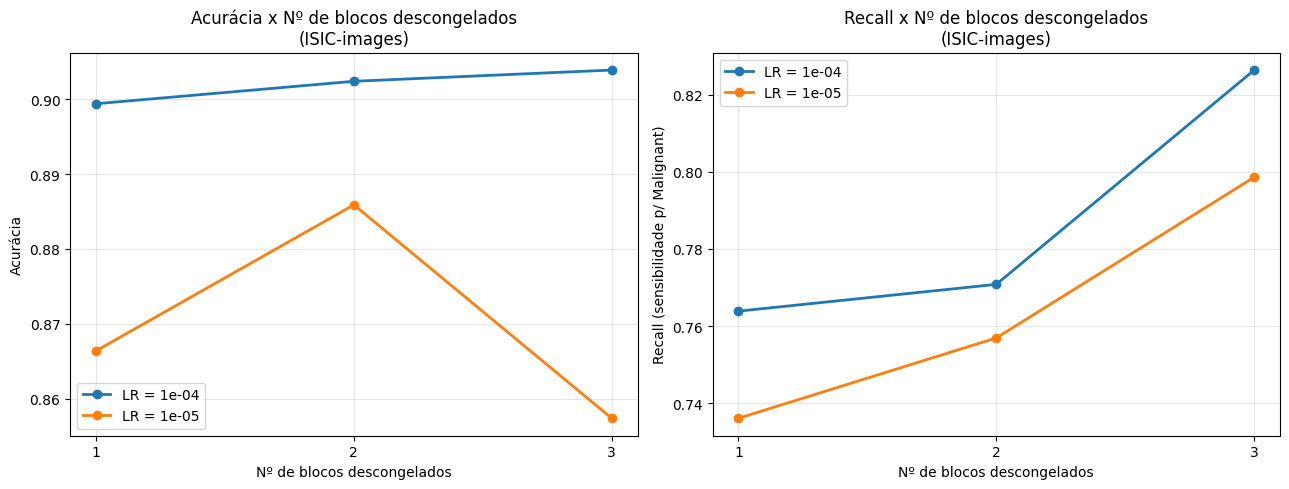


Resumo combinado (Teste padrão x ISIC-images):
      modelo      lr  blocos_descongelados  acc_teste  recall_teste  acc_isic  recall_isic
 LR1e-05_UL1 0.00001                     1   0.924574      0.989796  0.866366     0.736111
 LR1e-05_UL2 0.00001                     2   0.931873      1.000000  0.885886     0.756944
 LR1e-05_UL3 0.00001                     3   0.914842      1.000000  0.857357     0.798611
LR0.0001_UL1 0.00010                     1   0.948905      1.000000  0.899399     0.763889
LR0.0001_UL2 0.00010                     2   0.958637      1.000000  0.902402     0.770833
LR0.0001_UL3 0.00010                     3   0.929440      1.000000  0.903904     0.826389


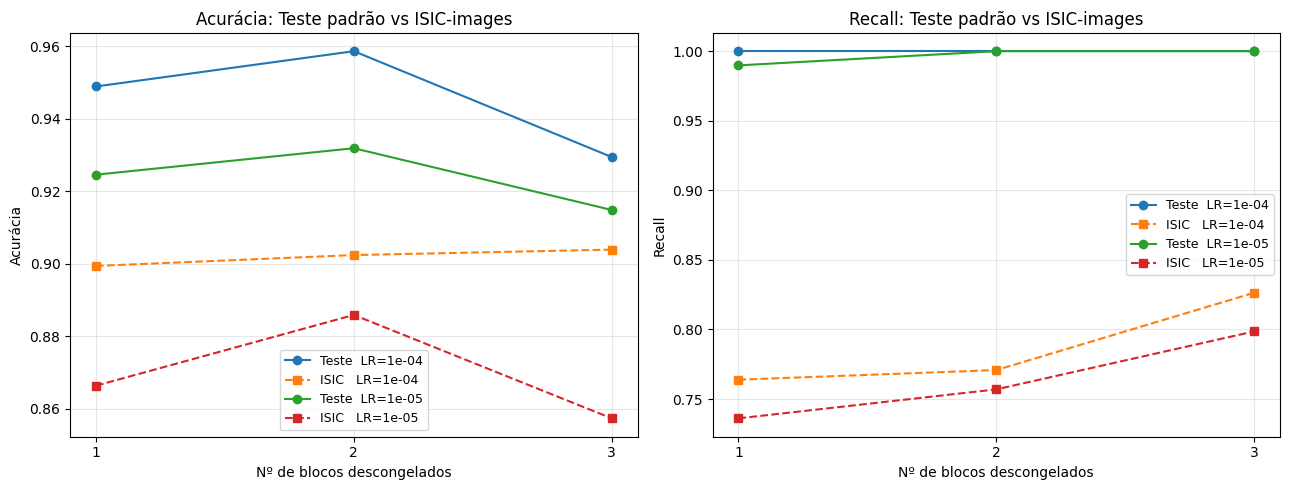


🏆 Melhor modelo (acurácia em ISIC-images): LR0.0001_UL3
   Acurácia: 0.9039
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 905ms/step

5 imagens classificadas ERRADO (LR0.0001_UL3):
  ISIC-images/ISIC_7272864.jpg
  ISIC-images/ISIC_4240489.jpg
  ISIC-images/ISIC_6047744.jpg
  ISIC-images/ISIC_0843685.jpg
  ISIC-images/ISIC_9536278.jpg


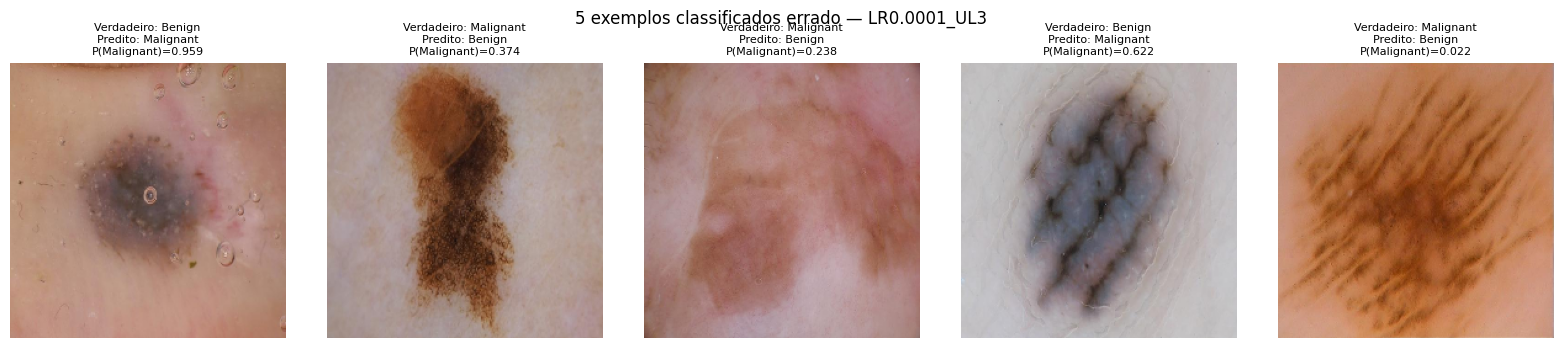


5 imagens classificadas CERTO (LR0.0001_UL3):
  ISIC-images/ISIC_9725825.jpg
  ISIC-images/ISIC_1051054.jpg
  ISIC-images/ISIC_5643394.jpg
  ISIC-images/ISIC_7692880.jpg
  ISIC-images/ISIC_7510067.jpg


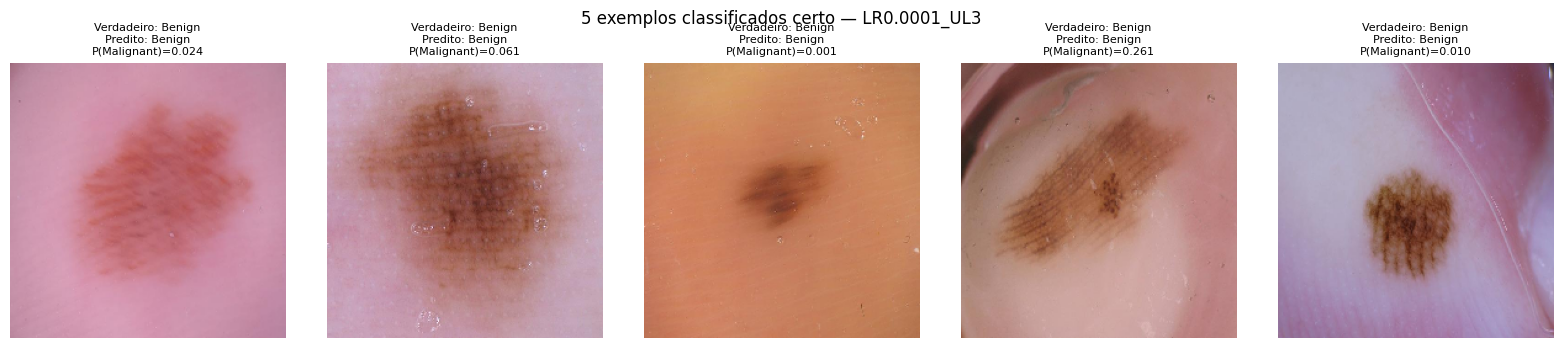

In [8]:
# === TESTE DOS 6 MODELOS NOS DOIS CONJUNTOS (TESTE PADRÃO + ISIC-images) ===
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

TAMANHO_B0    = (224, 224)
BATCH_SIZE    = 32
PASTA_MODELOS = os.path.join(CAMINHO_MODELOS, 'grid_unfrozen')
learning_rates       = [1e-4, 1e-5]
unfrozen_blocks_list = [1, 2, 3]

print("=== TESTANDO OS 6 MODELOS NOS DOIS CONJUNTOS ===\n")

# ------------------------------------------------------------------
# Gerador 1: conjunto de TESTE padrão (split do dataset de treino) — val_gen
# Gerador 2: conjunto EXTRA (ISIC-images)
# ------------------------------------------------------------------
datagen_teste = ImageDataGenerator()
extra_gen = datagen_teste.flow_from_dataframe(
    dataframe=df_isic_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

# Estruturas-alvo para cada conjunto
conjuntos = {
    "Teste padrão": {
        "gen":          val_gen,
        "y_true":       val_gen.classes,
        "class_labels": list(val_gen.class_indices.keys()),
        "caminhos":     val_gen.filepaths,
    },
    "ISIC-images": {
        "gen":          extra_gen,
        "y_true":       extra_gen.classes,
        "class_labels": list(extra_gen.class_indices.keys()),
        "caminhos":     df_isic_filtrado["caminho_imagem"].tolist(),
    },
}

for nome_conj, info in conjuntos.items():
    print(f"[{nome_conj}] Mapeamento de classes : {info['gen'].class_indices}")
    print(f"[{nome_conj}] Total de amostras     : {len(info['y_true'])}")
print()

resultados_test = {}   # nome_modelo -> {acc, recall, lr, n_unf}  (Teste padrão)
resultados_isic = {}   # nome_modelo -> {acc, recall, lr, n_unf}  (ISIC-images)

# -----------------------------------------------------------------------
# Loop sobre todos os 6 modelos treinados — avalia em AMBOS os conjuntos
# -----------------------------------------------------------------------
for lr in learning_rates:
    for n_unf in unfrozen_blocks_list:

        nome_modelo    = f"LR{lr}_UL{n_unf}"
        caminho_modelo = os.path.join(PASTA_MODELOS, f"{nome_modelo}.keras")

        if not os.path.exists(caminho_modelo):
            print(f"⚠️  Modelo não encontrado: {caminho_modelo}")
            continue

        print(f"\n{'='*60}")
        print(f"📊  AVALIANDO MODELO: {nome_modelo}")
        print(f"{'='*60}")

        tf.keras.backend.clear_session()
        gc.collect()

        modelo = tf.keras.models.load_model(caminho_modelo)

        # ---- Avalia no conjunto de TESTE padrão e no EXTRA (ISIC) ----
        metricas_modelo = {}
        for nome_conj, info in conjuntos.items():
            gen          = info["gen"]
            y_true       = info["y_true"]
            class_labels = info["class_labels"]

            gen.reset()
            preds  = modelo.predict(gen, verbose=1)
            y_pred = (preds > 0.5).astype(int).flatten()

            acc = accuracy_score(y_true, y_pred)
            rec = recall_score(y_true, y_pred)
            metricas_modelo[nome_conj] = {"acc": acc, "recall": rec,
                                          "y_pred": y_pred, "y_true": y_true,
                                          "class_labels": class_labels}

            print(f"\n[{nome_conj}] Relatório de Classificação ({nome_modelo}):")
            print(classification_report(y_true, y_pred,
                                        target_names=class_labels,
                                        digits=4, zero_division=0))

        # Salva nos dicionários de resultados de cada conjunto
        resultados_test[nome_modelo] = {
            "acc":    metricas_modelo["Teste padrão"]["acc"],
            "recall": metricas_modelo["Teste padrão"]["recall"],
            "lr": lr, "n_unf": n_unf,
        }
        resultados_isic[nome_modelo] = {
            "acc":    metricas_modelo["ISIC-images"]["acc"],
            "recall": metricas_modelo["ISIC-images"]["recall"],
            "lr": lr, "n_unf": n_unf,
        }

        # ---- Matrizes de confusão lado a lado (Teste padrão | ISIC) ----
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, nome_conj in zip(axes, conjuntos.keys()):
            m  = metricas_modelo[nome_conj]
            cm = confusion_matrix(m["y_true"], m["y_pred"])
            sns.heatmap(
                cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=m["class_labels"], yticklabels=m["class_labels"],
                ax=ax,
            )
            ax.set_title(f"Matriz de Confusão — {nome_modelo}\n({nome_conj})")
            ax.set_ylabel("Real")
            ax.set_xlabel("Predito")
        plt.tight_layout()
        plt.show()

        del modelo
        gc.collect()

print("\n✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!")

# ========================================================================
# GRÁFICOS COMPARATIVOS: acurácia e recall x nº de blocos descongelados
#   - Subplot 1: por conjunto (Teste padrão)
#   - Subplot 2: por conjunto (ISIC-images)
#   - Comparação direta Teste padrão vs ISIC-images em um único gráfico
# ========================================================================
if resultados_test and resultados_isic:
    # --- Gráficos por conjunto (acurácia | recall) ---
    for nome_conj, resultados in [("Teste padrão", resultados_test),
                                  ("ISIC-images",  resultados_isic)]:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for lr in learning_rates:
            xs      = [n for n in unfrozen_blocks_list if f"LR{lr}_UL{n}" in resultados]
            accs    = [resultados[f"LR{lr}_UL{n}"]["acc"]    for n in xs]
            recalls = [resultados[f"LR{lr}_UL{n}"]["recall"] for n in xs]
            axes[0].plot(xs, accs,    marker="o", linewidth=2, label=f"LR = {lr:.0e}")
            axes[1].plot(xs, recalls, marker="o", linewidth=2, label=f"LR = {lr:.0e}")

        axes[0].set_title(f"Acurácia x Nº de blocos descongelados\n({nome_conj})")
        axes[0].set_xlabel("Nº de blocos descongelados")
        axes[0].set_ylabel("Acurácia")
        axes[0].set_xticks(unfrozen_blocks_list)
        axes[0].grid(True, alpha=0.3); axes[0].legend()

        axes[1].set_title(f"Recall x Nº de blocos descongelados\n({nome_conj})")
        axes[1].set_xlabel("Nº de blocos descongelados")
        axes[1].set_ylabel("Recall (sensibilidade p/ Malignant)")
        axes[1].set_xticks(unfrozen_blocks_list)
        axes[1].grid(True, alpha=0.3); axes[1].legend()

        plt.tight_layout()
        plt.show()

    # --- Tabela-resumo combinada (Teste padrão + ISIC) ---
    linhas = []
    for nome in resultados_test:
        linhas.append({
            "modelo":               nome,
            "lr":                   resultados_test[nome]["lr"],
            "blocos_descongelados": resultados_test[nome]["n_unf"],
            "acc_teste":            resultados_test[nome]["acc"],
            "recall_teste":         resultados_test[nome]["recall"],
            "acc_isic":             resultados_isic.get(nome, {}).get("acc"),
            "recall_isic":          resultados_isic.get(nome, {}).get("recall"),
        })
    df_resumo = (pd.DataFrame(linhas)
                   .sort_values(["lr", "blocos_descongelados"])
                   .reset_index(drop=True))
    print("\nResumo combinado (Teste padrão x ISIC-images):")
    print(df_resumo.to_string(index=False))

    # --- Comparação direta Teste padrão vs ISIC-images ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for lr in learning_rates:
        xs = unfrozen_blocks_list
        acc_test  = [resultados_test.get(f"LR{lr}_UL{n}", {}).get("acc")    for n in xs]
        acc_isic  = [resultados_isic.get(f"LR{lr}_UL{n}", {}).get("acc")    for n in xs]
        rec_test  = [resultados_test.get(f"LR{lr}_UL{n}", {}).get("recall") for n in xs]
        rec_isic  = [resultados_isic.get(f"LR{lr}_UL{n}", {}).get("recall") for n in xs]

        axes[0].plot(xs, acc_test, marker="o", linestyle="-",  label=f"Teste  LR={lr:.0e}")
        axes[0].plot(xs, acc_isic, marker="s", linestyle="--", label=f"ISIC   LR={lr:.0e}")
        axes[1].plot(xs, rec_test, marker="o", linestyle="-",  label=f"Teste  LR={lr:.0e}")
        axes[1].plot(xs, rec_isic, marker="s", linestyle="--", label=f"ISIC   LR={lr:.0e}")

    axes[0].set_title("Acurácia: Teste padrão vs ISIC-images")
    axes[0].set_xlabel("Nº de blocos descongelados")
    axes[0].set_ylabel("Acurácia")
    axes[0].set_xticks(unfrozen_blocks_list)
    axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=9)

    axes[1].set_title("Recall: Teste padrão vs ISIC-images")
    axes[1].set_xlabel("Nº de blocos descongelados")
    axes[1].set_ylabel("Recall")
    axes[1].set_xticks(unfrozen_blocks_list)
    axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# Aliases mantidos para compatibilidade com o restante do notebook
test_gen          = extra_gen
y_true            = extra_gen.classes
class_labels      = list(extra_gen.class_indices.keys())
caminhos_img      = df_isic_filtrado["caminho_imagem"].tolist()
resultados_acc    = {k: v["acc"]    for k, v in resultados_isic.items()}
resultados_recall = {k: v["recall"] for k, v in resultados_isic.items()}

# -----------------------------------------------------------------------
# Melhor modelo (maior acurácia em ISIC-images): 5 erros e 5 acertos
# -----------------------------------------------------------------------
if not resultados_acc:
    print("Nenhum modelo foi avaliado — não há exemplos para exibir.")
else:
    melhor_nome = max(resultados_acc, key=resultados_acc.get)
    print(f"\n{'='*60}")
    print(f"🏆 Melhor modelo (acurácia em ISIC-images): {melhor_nome}")
    print(f"   Acurácia: {resultados_acc[melhor_nome]:.4f}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    gc.collect()
    modelo_melhor = tf.keras.models.load_model(
        os.path.join(PASTA_MODELOS, f"{melhor_nome}.keras")
    )
    test_gen.reset()
    probs_melhor = modelo_melhor.predict(test_gen, verbose=1)
    y_pred_melhor = (probs_melhor > 0.5).astype(int).flatten()
    del modelo_melhor
    gc.collect()

    err_idx = np.where(y_pred_melhor != y_true)[0]
    ok_idx  = np.where(y_pred_melhor == y_true)[0]

    rng = np.random.default_rng(42)
    n_err = min(5, len(err_idx))
    n_ok  = min(5, len(ok_idx))
    err_pick = rng.choice(err_idx, size=n_err, replace=False) if n_err > 0 else np.array([], dtype=int)
    ok_pick  = rng.choice(ok_idx,  size=n_ok,  replace=False) if n_ok > 0  else np.array([], dtype=int)

    def _titulo(idx):
        v = class_labels[int(y_true[idx])]
        p = class_labels[int(y_pred_melhor[idx])]
        pr_mal = float(probs_melhor[idx].ravel()[0])
        return f"Verdadeiro: {v}\nPredito: {p}\nP(Malignant)={pr_mal:.3f}"

    if n_err > 0:
        print(f"\n5 imagens classificadas ERRADO ({melhor_nome}):")
        for idx in err_pick:
            print(" ", caminhos_img[idx])
        fig, axes = plt.subplots(1, n_err, figsize=(3.2 * n_err, 3.5))
        if n_err == 1:
            axes = [axes]
        fig.suptitle(f"5 exemplos classificados errado — {melhor_nome}", fontsize=12)
        for ax, idx in zip(axes, err_pick):
            img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
            ax.imshow(img)
            ax.set_title(_titulo(idx), fontsize=8)
            ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("(Nenhum erro no conjunto — não há 5 imagens erradas para mostrar.)")

    if n_ok > 0:
        print(f"\n5 imagens classificadas CERTO ({melhor_nome}):")
        for idx in ok_pick:
            print(" ", caminhos_img[idx])
        fig, axes = plt.subplots(1, n_ok, figsize=(3.2 * n_ok, 3.5))
        if n_ok == 1:
            axes = [axes]
        fig.suptitle(f"5 exemplos classificados certo — {melhor_nome}", fontsize=12)
        for ax, idx in zip(axes, ok_pick):
            img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
            ax.imshow(img)
            ax.set_title(_titulo(idx), fontsize=8)
            ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("(Nenhum acerto no conjunto — não há imagens corretas para mostrar.)")


## Avaliação dos modelos (LR × Dropout)

Mesma rotina aplicada aos 6 modelos do grid `LR × Nº de blocos descongelados`,
porém agora para os 6 modelos do grid antigo `LR × Dropout`. Avaliação em ambos os conjuntos (teste padrão + ISIC-images), com matrizes de confusão, gráficos comparativos e tabela-resumo.

=== TESTANDO MODELOS DE 'Modelos/treino_Modelos' EM AMBOS OS CONJUNTOS ===

6 modelos encontrados:
  - LR0.0001_DO0.4  (LR=0.0001, DO=0.4)
  - LR0.0001_DO0.5  (LR=0.0001, DO=0.5)
  - LR0.001_DO0.4  (LR=0.001, DO=0.4)
  - LR0.001_DO0.5  (LR=0.001, DO=0.5)
  - LR1e-05_DO0.4  (LR=1e-05, DO=0.4)
  - LR1e-05_DO0.5  (LR=1e-05, DO=0.5)

Found 666 validated image filenames belonging to 2 classes.
[Teste padrão] Mapeamento de classes : {'Benign': 0, 'Malignant': 1}
[Teste padrão] Total de amostras     : 411
[ISIC-images] Mapeamento de classes : {'Benign': 0, 'Malignant': 1}
[ISIC-images] Total de amostras     : 666


📊  AVALIANDO MODELO: LR0.0001_DO0.4


I0000 00:00:1778513470.314688   49919 service.cc:153] XLA service 0x7fcfe428a0d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778513470.314709   49919 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1778513470.397523   49919 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778513471.350934   49919 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 5s/step

[Teste padrão] Relatório de Classificação (LR0.0001_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9936    0.9968       313
   Malignant     0.9800    1.0000    0.9899        98

    accuracy                         0.9951       411
   macro avg     0.9900    0.9968    0.9933       411
weighted avg     0.9952    0.9951    0.9952       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step

[ISIC-images] Relatório de Classificação (LR0.0001_DO0.4):
              precision    recall  f1-score   support

      Benign     0.9123    0.9368    0.9244       522
   Malignant     0.7462    0.6736    0.7080       144

    accuracy                         0.8799       666
   macro avg     0.8292    0.8052    0.8162       666
weighted avg     0.8764    0.8799    0.8776       666



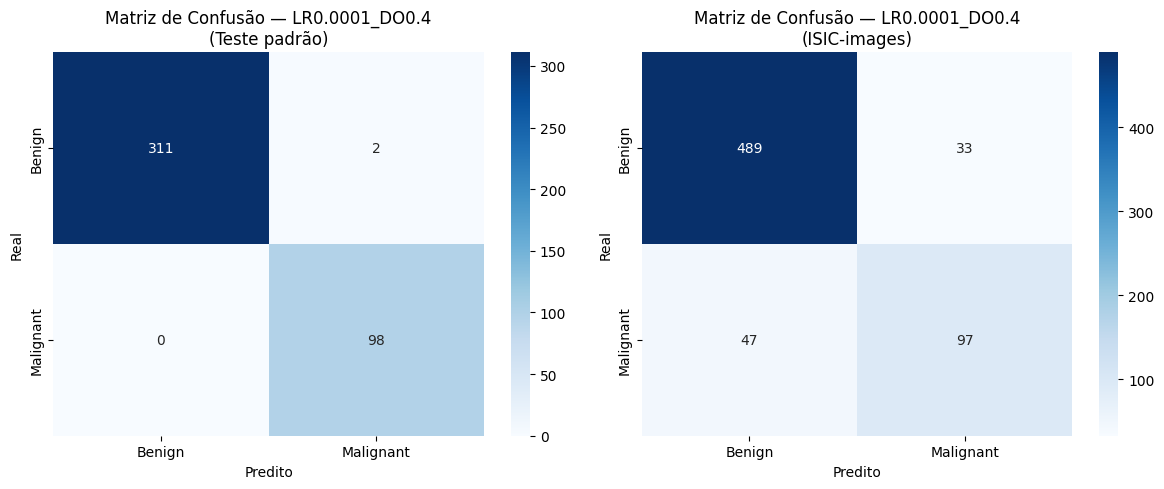


📊  AVALIANDO MODELO: LR0.0001_DO0.5
13/13 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step

[Teste padrão] Relatório de Classificação (LR0.0001_DO0.5):
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000       313
   Malignant     1.0000    1.0000    1.0000        98

    accuracy                         1.0000       411
   macro avg     1.0000    1.0000    1.0000       411
weighted avg     1.0000    1.0000    1.0000       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step

[ISIC-images] Relatório de Classificação (LR0.0001_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9227    0.9598    0.9408       522
   Malignant     0.8293    0.7083    0.7640       144

    accuracy                         0.9054       666
   macro avg     0.8760    0.8341    0.8524       666
weighted avg     0.9025    0.9054    0.9026       666



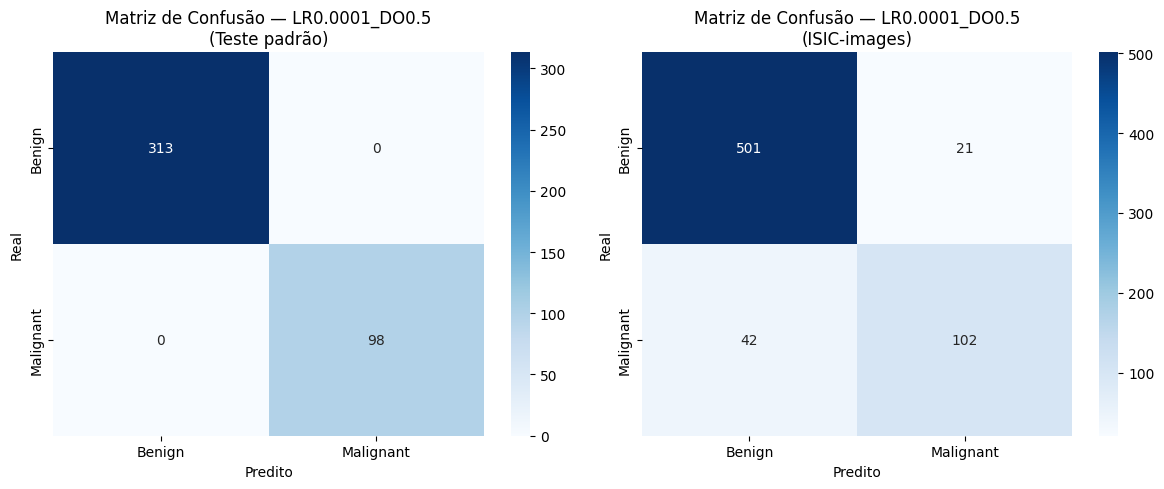


📊  AVALIANDO MODELO: LR0.001_DO0.4
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step

[Teste padrão] Relatório de Classificação (LR0.001_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9936    0.9968       313
   Malignant     0.9800    1.0000    0.9899        98

    accuracy                         0.9951       411
   macro avg     0.9900    0.9968    0.9933       411
weighted avg     0.9952    0.9951    0.9952       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 855ms/step

[ISIC-images] Relatório de Classificação (LR0.001_DO0.4):
              precision    recall  f1-score   support

      Benign     0.8899    0.9598    0.9235       522
   Malignant     0.7961    0.5694    0.6640       144

    accuracy                         0.8754       666
   macro avg     0.8430    0.7646    0.7937       666
weighted avg     0.8696    0.8754    0.8674       666



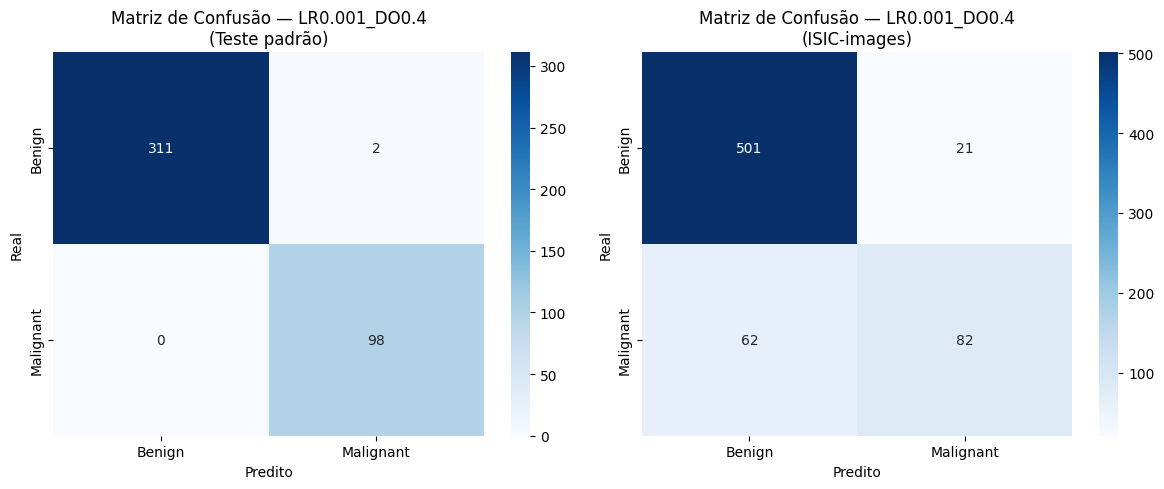


📊  AVALIANDO MODELO: LR0.001_DO0.5
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

[Teste padrão] Relatório de Classificação (LR0.001_DO0.5):
              precision    recall  f1-score   support

      Benign     1.0000    0.9872    0.9936       313
   Malignant     0.9608    1.0000    0.9800        98

    accuracy                         0.9903       411
   macro avg     0.9804    0.9936    0.9868       411
weighted avg     0.9906    0.9903    0.9903       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 857ms/step

[ISIC-images] Relatório de Classificação (LR0.001_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9315    0.8333    0.8797       522
   Malignant     0.5628    0.7778    0.6531       144

    accuracy                         0.8213       666
   macro avg     0.7471    0.8056    0.7664       666
weighted avg     0.8518    0.8213    0.8307       666



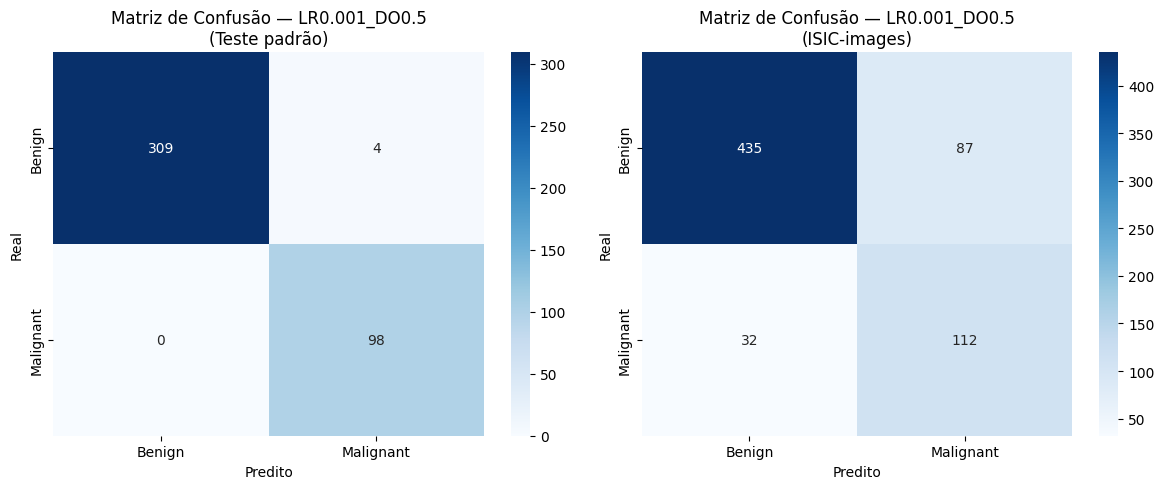


📊  AVALIANDO MODELO: LR1e-05_DO0.4
13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step

[Teste padrão] Relatório de Classificação (LR1e-05_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9233    0.9601       313
   Malignant     0.8033    1.0000    0.8909        98

    accuracy                         0.9416       411
   macro avg     0.9016    0.9617    0.9255       411
weighted avg     0.9531    0.9416    0.9436       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step

[ISIC-images] Relatório de Classificação (LR1e-05_DO0.4):
              precision    recall  f1-score   support

      Benign     0.9400    0.8697    0.9035       522
   Malignant     0.6284    0.7986    0.7034       144

    accuracy                         0.8544       666
   macro avg     0.7842    0.8342    0.8034       666
weighted avg     0.8726    0.8544    0.8602       666



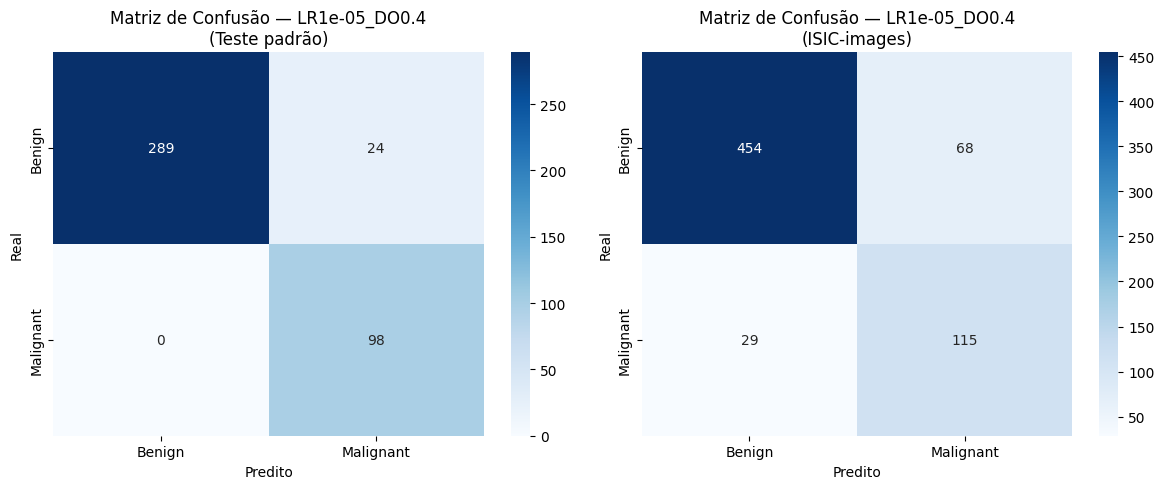


📊  AVALIANDO MODELO: LR1e-05_DO0.5
13/13 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step

[Teste padrão] Relatório de Classificação (LR1e-05_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9965    0.9042    0.9481       313
   Malignant     0.7638    0.9898    0.8622        98

    accuracy                         0.9246       411
   macro avg     0.8801    0.9470    0.9051       411
weighted avg     0.9410    0.9246    0.9276       411

21/21 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step

[ISIC-images] Relatório de Classificação (LR1e-05_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9415    0.8640    0.9011       522
   Malignant     0.6203    0.8056    0.7009       144

    accuracy                         0.8514       666
   macro avg     0.7809    0.8348    0.8010       666
weighted avg     0.8721    0.8514    0.8578       666



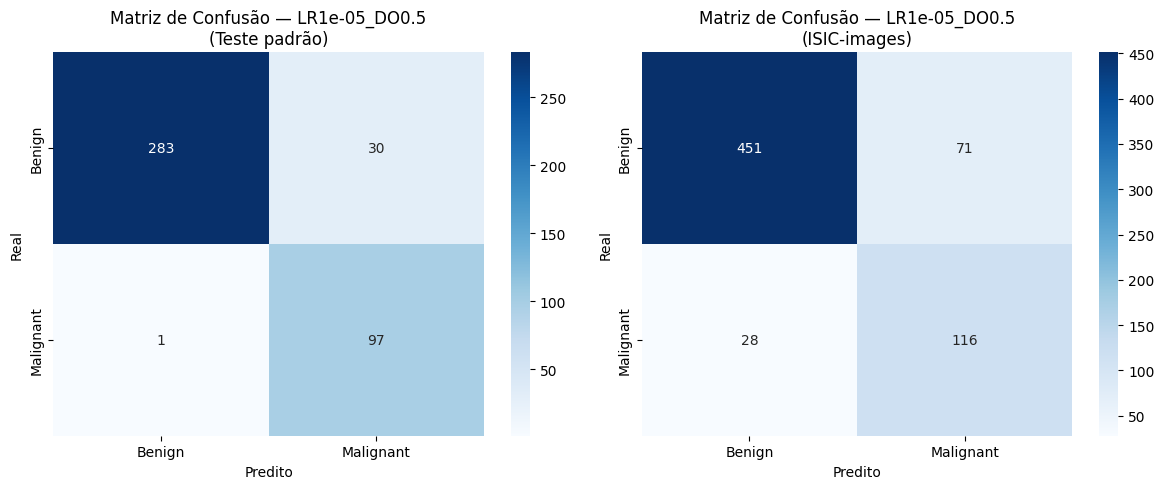


✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!


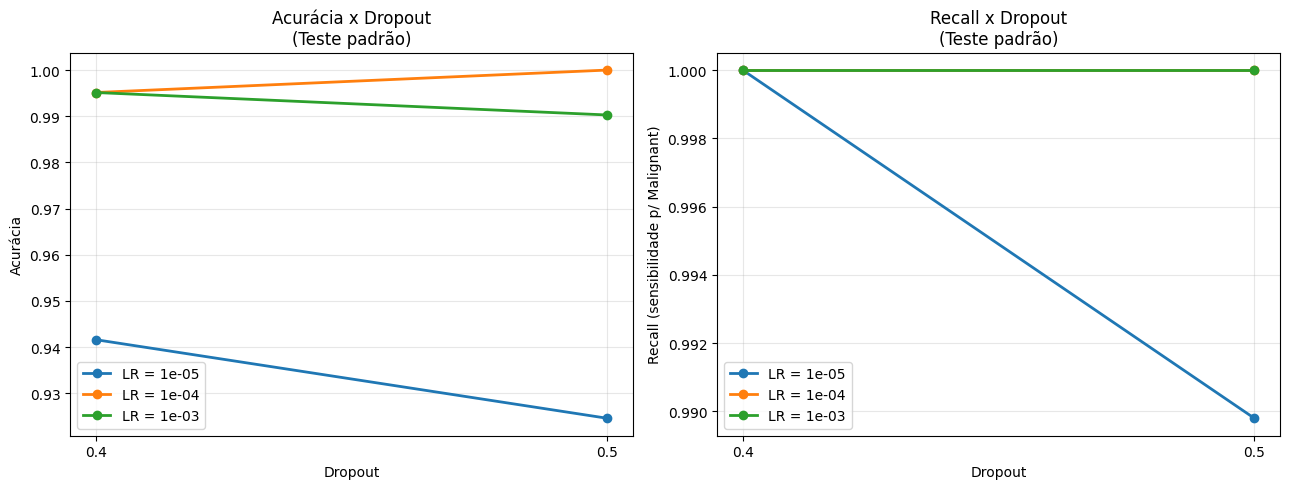

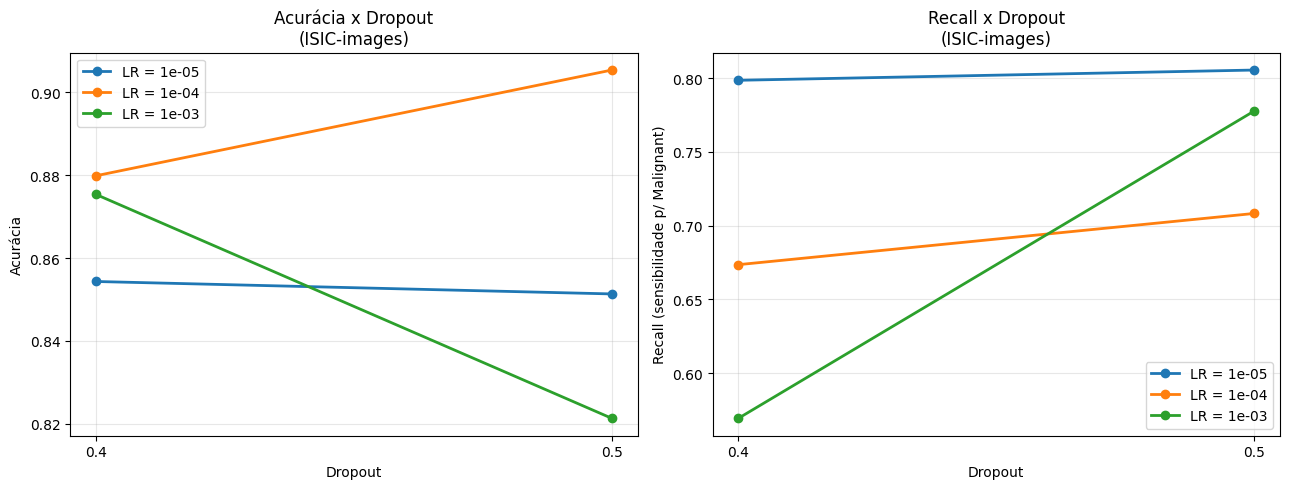


Resumo combinado (Teste padrão x ISIC-images) — LR x Dropout:
        modelo      lr  dropout  acc_teste  recall_teste  acc_isic  recall_isic
 LR1e-05_DO0.4 0.00001      0.4   0.941606      1.000000  0.854354     0.798611
 LR1e-05_DO0.5 0.00001      0.5   0.924574      0.989796  0.851351     0.805556
LR0.0001_DO0.4 0.00010      0.4   0.995134      1.000000  0.879880     0.673611
LR0.0001_DO0.5 0.00010      0.5   1.000000      1.000000  0.905405     0.708333
 LR0.001_DO0.4 0.00100      0.4   0.995134      1.000000  0.875375     0.569444
 LR0.001_DO0.5 0.00100      0.5   0.990268      1.000000  0.821321     0.777778


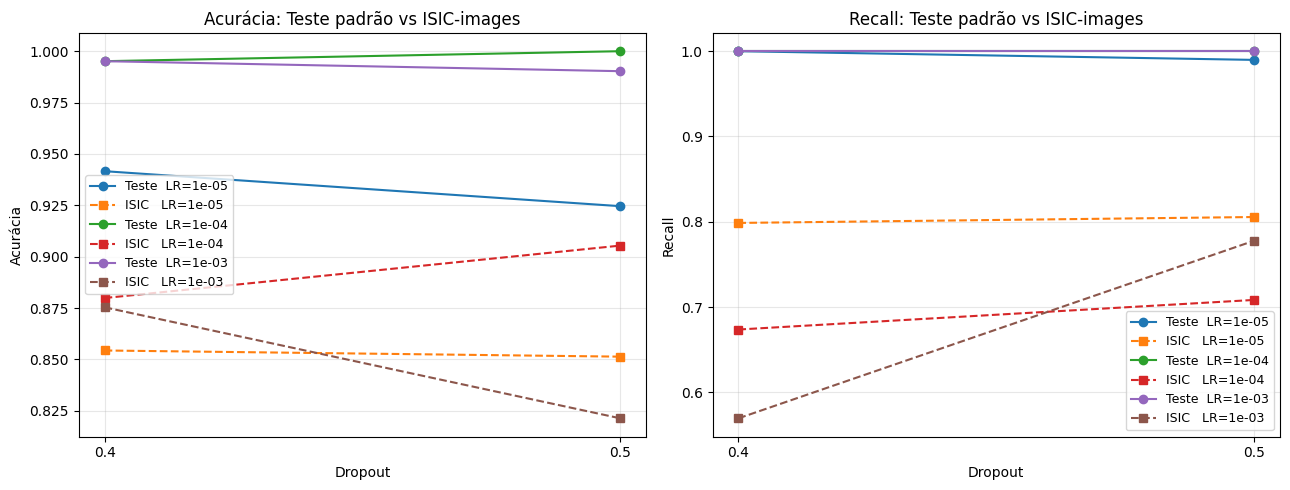

In [9]:
# === TESTE DOS 6 MODELOS (LR x Dropout) EM AMBOS OS CONJUNTOS ===
import re
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

TAMANHO_B0       = (224, 224)
BATCH_SIZE       = 32
PASTA_MODELOS_DO = os.path.join(CAMINHO_MODELOS, "treino_Modelos")

print(f"=== TESTANDO MODELOS DE '{PASTA_MODELOS_DO}' EM AMBOS OS CONJUNTOS ===\n")

# Descobre dinamicamente os 6 (LR, DO) disponíveis na pasta
padrao = re.compile(r"^LR(?P<lr>[0-9.e\-]+)_DO(?P<do>[0-9.]+)\.keras$")
modelos_disponiveis = []
for fname in sorted(os.listdir(PASTA_MODELOS_DO)):
    m = padrao.match(fname)
    if m:
        modelos_disponiveis.append({
            "nome":    fname[:-len(".keras")],
            "arquivo": os.path.join(PASTA_MODELOS_DO, fname),
            "lr":      float(m.group("lr")),
            "do":      float(m.group("do")),
        })

print(f"{len(modelos_disponiveis)} modelos encontrados:")
for m in modelos_disponiveis:
    print(f"  - {m['nome']}  (LR={m['lr']}, DO={m['do']})")
print()

# ------------------------------------------------------------------
# Geradores: teste padrão (val_gen, já existe) + extra (ISIC-images)
# ------------------------------------------------------------------
datagen_teste_do = ImageDataGenerator()
extra_gen_do = datagen_teste_do.flow_from_dataframe(
    dataframe=df_isic_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

conjuntos = {
    "Teste padrão": {
        "gen":          val_gen,
        "y_true":       val_gen.classes,
        "class_labels": list(val_gen.class_indices.keys()),
    },
    "ISIC-images": {
        "gen":          extra_gen_do,
        "y_true":       extra_gen_do.classes,
        "class_labels": list(extra_gen_do.class_indices.keys()),
    },
}

for nome_conj, info in conjuntos.items():
    print(f"[{nome_conj}] Mapeamento de classes : {info['gen'].class_indices}")
    print(f"[{nome_conj}] Total de amostras     : {len(info['y_true'])}")
print()

resultados_test_do = {}   # nome_modelo -> {acc, recall, lr, do}  (Teste padrão)
resultados_isic_do = {}   # nome_modelo -> {acc, recall, lr, do}  (ISIC-images)

# -----------------------------------------------------------------------
# Loop sobre todos os modelos encontrados
# -----------------------------------------------------------------------
for m in modelos_disponiveis:
    nome_modelo    = m["nome"]
    caminho_modelo = m["arquivo"]
    lr             = m["lr"]
    do             = m["do"]

    print(f"\n{'='*60}")
    print(f"📊  AVALIANDO MODELO: {nome_modelo}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    gc.collect()

    modelo = tf.keras.models.load_model(caminho_modelo)

    metricas_modelo = {}
    for nome_conj, info in conjuntos.items():
        gen          = info["gen"]
        y_true       = info["y_true"]
        class_labels = info["class_labels"]

        gen.reset()
        preds  = modelo.predict(gen, verbose=1)
        y_pred = (preds > 0.5).astype(int).flatten()

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        metricas_modelo[nome_conj] = {"acc": acc, "recall": rec,
                                      "y_pred": y_pred, "y_true": y_true,
                                      "class_labels": class_labels}

        print(f"\n[{nome_conj}] Relatório de Classificação ({nome_modelo}):")
        print(classification_report(y_true, y_pred,
                                    target_names=class_labels,
                                    digits=4, zero_division=0))

    resultados_test_do[nome_modelo] = {
        "acc":    metricas_modelo["Teste padrão"]["acc"],
        "recall": metricas_modelo["Teste padrão"]["recall"],
        "lr": lr, "do": do,
    }
    resultados_isic_do[nome_modelo] = {
        "acc":    metricas_modelo["ISIC-images"]["acc"],
        "recall": metricas_modelo["ISIC-images"]["recall"],
        "lr": lr, "do": do,
    }

    # ---- Matrizes de confusão lado a lado (Teste padrão | ISIC) ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, nome_conj in zip(axes, conjuntos.keys()):
        mm = metricas_modelo[nome_conj]
        cm = confusion_matrix(mm["y_true"], mm["y_pred"])
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=mm["class_labels"], yticklabels=mm["class_labels"],
            ax=ax,
        )
        ax.set_title(f"Matriz de Confusão — {nome_modelo}\n({nome_conj})")
        ax.set_ylabel("Real")
        ax.set_xlabel("Predito")
    plt.tight_layout()
    plt.show()

    del modelo
    gc.collect()

print("\n✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!")

# ========================================================================
# GRÁFICOS COMPARATIVOS: acurácia e recall x Dropout (uma curva por LR)
# ========================================================================
if resultados_test_do and resultados_isic_do:
    lrs_unicos = sorted({d["lr"] for d in resultados_test_do.values()})
    dos_unicos = sorted({d["do"] for d in resultados_test_do.values()})

    # --- Gráficos por conjunto (acurácia | recall) ---
    for nome_conj, resultados in [("Teste padrão", resultados_test_do),
                                  ("ISIC-images",  resultados_isic_do)]:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for lr in lrs_unicos:
            pts = sorted(
                [(d["do"], d["acc"], d["recall"])
                 for d in resultados.values() if d["lr"] == lr]
            )
            if not pts:
                continue
            xs, accs, recalls = zip(*pts)
            axes[0].plot(xs, accs,    marker="o", linewidth=2, label=f"LR = {lr:.0e}")
            axes[1].plot(xs, recalls, marker="o", linewidth=2, label=f"LR = {lr:.0e}")

        axes[0].set_title(f"Acurácia x Dropout\n({nome_conj})")
        axes[0].set_xlabel("Dropout"); axes[0].set_ylabel("Acurácia")
        axes[0].set_xticks(dos_unicos)
        axes[0].grid(True, alpha=0.3); axes[0].legend()

        axes[1].set_title(f"Recall x Dropout\n({nome_conj})")
        axes[1].set_xlabel("Dropout"); axes[1].set_ylabel("Recall (sensibilidade p/ Malignant)")
        axes[1].set_xticks(dos_unicos)
        axes[1].grid(True, alpha=0.3); axes[1].legend()

        plt.tight_layout()
        plt.show()

    # --- Tabela-resumo combinada ---
    linhas = []
    for nome in resultados_test_do:
        linhas.append({
            "modelo":       nome,
            "lr":           resultados_test_do[nome]["lr"],
            "dropout":      resultados_test_do[nome]["do"],
            "acc_teste":    resultados_test_do[nome]["acc"],
            "recall_teste": resultados_test_do[nome]["recall"],
            "acc_isic":     resultados_isic_do.get(nome, {}).get("acc"),
            "recall_isic":  resultados_isic_do.get(nome, {}).get("recall"),
        })
    df_resumo_do = (pd.DataFrame(linhas)
                      .sort_values(["lr", "dropout"])
                      .reset_index(drop=True))
    print("\nResumo combinado (Teste padrão x ISIC-images) — LR x Dropout:")
    print(df_resumo_do.to_string(index=False))

    # --- Comparação direta Teste padrão vs ISIC-images ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for lr in lrs_unicos:
        pts_t = sorted(
            [(d["do"], d["acc"], d["recall"])
             for d in resultados_test_do.values() if d["lr"] == lr]
        )
        pts_i = sorted(
            [(d["do"], d["acc"], d["recall"])
             for d in resultados_isic_do.values() if d["lr"] == lr]
        )
        if not pts_t or not pts_i:
            continue
        xs_t, acc_t, rec_t = zip(*pts_t)
        xs_i, acc_i, rec_i = zip(*pts_i)

        axes[0].plot(xs_t, acc_t, marker="o", linestyle="-",  label=f"Teste  LR={lr:.0e}")
        axes[0].plot(xs_i, acc_i, marker="s", linestyle="--", label=f"ISIC   LR={lr:.0e}")
        axes[1].plot(xs_t, rec_t, marker="o", linestyle="-",  label=f"Teste  LR={lr:.0e}")
        axes[1].plot(xs_i, rec_i, marker="s", linestyle="--", label=f"ISIC   LR={lr:.0e}")

    axes[0].set_title("Acurácia: Teste padrão vs ISIC-images")
    axes[0].set_xlabel("Dropout"); axes[0].set_ylabel("Acurácia")
    axes[0].set_xticks(dos_unicos)
    axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=9)

    axes[1].set_title("Recall: Teste padrão vs ISIC-images")
    axes[1].set_xlabel("Dropout"); axes[1].set_ylabel("Recall")
    axes[1].set_xticks(dos_unicos)
    axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()